In [1]:
from sklearn.datasets import fetch_lfw_people
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from mtcnn import MTCNN
from keras_vggface.vggface import VGGFace
from keras_vggface.utils import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
import cv2
import warnings
warnings.filterwarnings('ignore')

/Users/camillew/miniforge3/envs/face_recognition/lib/python3.9/site-packages/mtcnn/mtcnn.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# load LFW dataset. require at least 30 images per person
# imgs per individual for meaningful clustering
lfw = fetch_lfw_people(min_faces_per_person=30, resize=1.0, color=True)

images = lfw.images  # shape: (n_samples, h, w, 3), values in [0, 255]
labels = lfw.target
target_names = lfw.target_names

print(f"Dataset shape: {images.shape}")
print(f"Number of people with >= 30 images: {len(target_names)}")
print(f"People: {target_names}")

Dataset shape: (2370, 125, 94, 3)
Number of people with >= 30 images: 34
People: ['Alejandro Toledo' 'Alvaro Uribe' 'Andre Agassi' 'Ariel Sharon'
 'Arnold Schwarzenegger' 'Colin Powell' 'David Beckham' 'Donald Rumsfeld'
 'George W Bush' 'Gerhard Schroeder' 'Gloria Macapagal Arroyo'
 'Guillermo Coria' 'Hans Blix' 'Hugo Chavez' 'Jacques Chirac'
 'Jean Chretien' 'Jennifer Capriati' 'John Ashcroft' 'John Negroponte'
 'Junichiro Koizumi' 'Kofi Annan' 'Laura Bush' 'Lleyton Hewitt'
 'Luiz Inacio Lula da Silva' 'Megawati Sukarnoputri' 'Nestor Kirchner'
 'Recep Tayyip Erdogan' 'Roh Moo-hyun' 'Serena Williams'
 'Silvio Berlusconi' 'Tom Ridge' 'Tony Blair' 'Vicente Fox'
 'Vladimir Putin']


In [3]:
# randomly select 10 individuals
np.random.seed(42)
num_people = min(10, len(target_names))
selected_indices = np.random.choice(len(target_names), size=num_people, replace=False)
selected_names = target_names[selected_indices]

print(f"selected {num_people} individuals:")
for name in selected_names:
    count = np.sum(labels == np.where(target_names == name)[0][0])
    print(f"  {name}: {count} images")

selected 10 individuals:
  Jean Chretien: 55 images
  Junichiro Koizumi: 60 images
  Roh Moo-hyun: 32 images
  Recep Tayyip Erdogan: 30 images
  George W Bush: 530 images
  Megawati Sukarnoputri: 33 images
  Laura Bush: 41 images
  Hans Blix: 39 images
  Vicente Fox: 32 images
  Gerhard Schroeder: 109 images


In [4]:
# ONLY include selected individuals
mask = np.isin(labels, selected_indices)
filtered_images = images[mask]
filtered_labels = labels[mask]

# create a mapping from old label indices to new 0..9 indices
label_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(selected_indices)}
mapped_labels = np.array([label_mapping[l] for l in filtered_labels])

print(f"filtered dataset: {filtered_images.shape[0]} imgs of {num_people} people")

filtered dataset: 961 imgs of 10 people


In [5]:
# MTCNN (Face Detection)
detector = MTCNN()

def detect_and_crop_face(image, detector, target_size=(224, 224)):
    """
    Detect face using MTCNN, crop the detected region,
    resize to 224x224, and normalize pixel values to [0, 1].
    
    Returns the preprocessed face or None if no face detected.
    """
    # uint8 for MTCNN
    if image.dtype != np.uint8:
        img_uint8 = (image * 255).astype(np.uint8) if image.max() <= 1.0 else image.astype(np.uint8)
    else:
        img_uint8 = image
    
    # detect faces
    results = detector.detect_faces(img_uint8)
    
    if len(results) == 0:
        return None
    
    # max(confidence)
    best = max(results, key=lambda x: x['confidence'])
    x, y, w, h = best['box']
    
    # bbox dims
    x, y = max(0, x), max(0, y)
    x2 = min(img_uint8.shape[1], x + w)
    y2 = min(img_uint8.shape[0], y + h)
    
    # crop the face region
    face = img_uint8[y:y2, x:x2]
    
    # resize to target size
    face_resized = cv2.resize(face, target_size)
    
    # norm to [0, 1]
    face_normalized = face_resized.astype(np.float32) / 255.0
    
    return face_normalized

In [6]:
# detect and crop faces for all filtered images
cropped_faces = []
valid_labels = []

print(f"num {len(filtered_images)} imgs")
for i, (img, label) in enumerate(zip(filtered_images, mapped_labels)):
    face = detect_and_crop_face(img, detector)
    if face is not None:
        cropped_faces.append(face)
        valid_labels.append(label)
    
    if (i + 1) % 50 == 0:
        print(f"  processed {i + 1}/{len(filtered_images)} images...")

cropped_faces = np.array(cropped_faces)
valid_labels = np.array(valid_labels)

print(f"\nsuccessfully detected faces: {len(cropped_faces)} / {len(filtered_images)}")
print(f"cropped faces shape: {cropped_faces.shape}")

num 961 imgs
1/1 [==============================] - 0s 11ms/step
  processed 50/961 images...
1/1 [==============================] - 0s 17ms/step
  processed 100/961 images...
1/1 [==============================] - 0s 20ms/step
  processed 150/961 images...
1/1 [==============================] - 0s 12ms/step
  processed 200/961 images...
1/1 [==============================] - 0s 22ms/step
  processed 250/961 images...
1/1 [==============================] - 0s 10ms/step
  processed 300/961 images...
1/1 [==============================] - 0s 20ms/step
  processed 350/961 images...
1/1 [==============================] - 0s 9ms/step
  processed 400/961 images...
1/1 [==============================] - 0s 9ms/step
  processed 450/961 images...
1/1 [==============================] - 0s 10ms/step
  processed 500/961 images...
1/1 [==============================] - 0s 10ms/step
  processed 550/961 images...
1/1 [==============================] - 0s 11ms/step
  processed 600/961 images...
1/1 [=

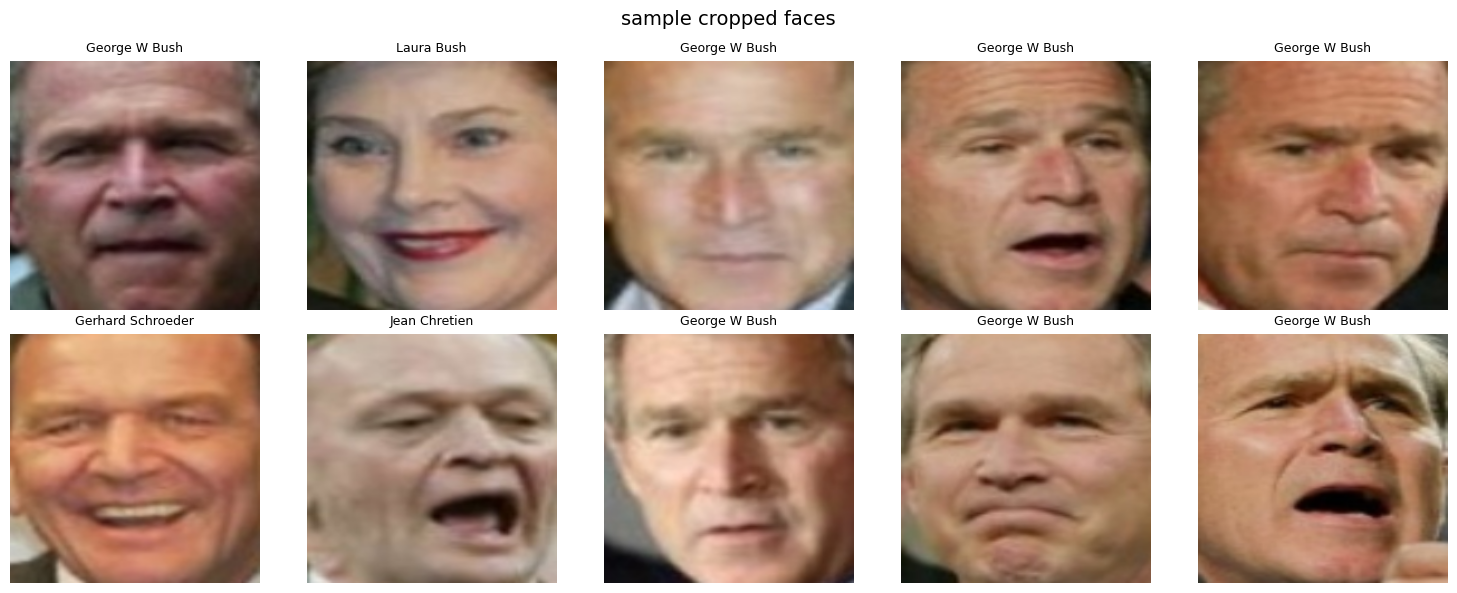

In [7]:
# DEBUG print a few sample cropped faces
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(cropped_faces):
        ax.imshow(cropped_faces[i])
        ax.set_title(selected_names[valid_labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('sample cropped faces', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# VGGFace2 (Face Feature Extraction)
# model='resnet50' with include_top=False gives 2048-dim embeddings
vggface_model = VGGFace(
    model='resnet50',
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg'  # global avg pooling -> 2048-dim output
)

print(f"VGGFace2 model loaded.")
print(f"Output shape: {vggface_model.output_shape}")

94699520/94694792 [==============================] - 9s 0us/step
VGGFace2 model loaded.
Output shape: (None, 2048)


In [9]:
# prep faces for VGGFace2 - needs version 2 preprocessing
# scale back to [0, 255] for preprocess_input
faces_for_model = (cropped_faces * 255).astype(np.float32)
faces_preprocessed = preprocess_input(faces_for_model, version=2)

# Extract embeddings in batches to manage memory
batch_size = 32
embeddings_list = []

print(f"Extracting embeddings for {len(faces_preprocessed)} faces...")
for i in range(0, len(faces_preprocessed), batch_size):
    batch = faces_preprocessed[i:i + batch_size]
    batch_embeddings = vggface_model.predict(batch, verbose=0)
    embeddings_list.append(batch_embeddings)
    print(f"  Batch {i // batch_size + 1}/{(len(faces_preprocessed) - 1) // batch_size + 1} done")

embeddings = np.vstack(embeddings_list)
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Each face is represented as a {embeddings.shape[1]}-dimensional vector.")

Extracting embeddings for 959 faces...
  Batch 1/30 done
  Batch 2/30 done
  Batch 3/30 done
  Batch 4/30 done
  Batch 5/30 done
  Batch 6/30 done
  Batch 7/30 done
  Batch 8/30 done
  Batch 9/30 done
  Batch 10/30 done
  Batch 11/30 done
  Batch 12/30 done
  Batch 13/30 done
  Batch 14/30 done
  Batch 15/30 done
  Batch 16/30 done
  Batch 17/30 done
  Batch 18/30 done
  Batch 19/30 done
  Batch 20/30 done
  Batch 21/30 done
  Batch 22/30 done
  Batch 23/30 done
  Batch 24/30 done
  Batch 25/30 done
  Batch 26/30 done
  Batch 27/30 done
  Batch 28/30 done
  Batch 29/30 done
  Batch 30/30 done

Embeddings shape: (959, 2048)
Each face is represented as a 2048-dimensional vector.


In [10]:
# t-SNE (Visualization)
# reduce 2048->2 dim
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=1000,
    learning_rate='auto',
    init='pca'
)

embeddings_2d = tsne.fit_transform(embeddings)
print(f"t-SNE output shape: {embeddings_2d.shape}")

t-SNE output shape: (959, 2)


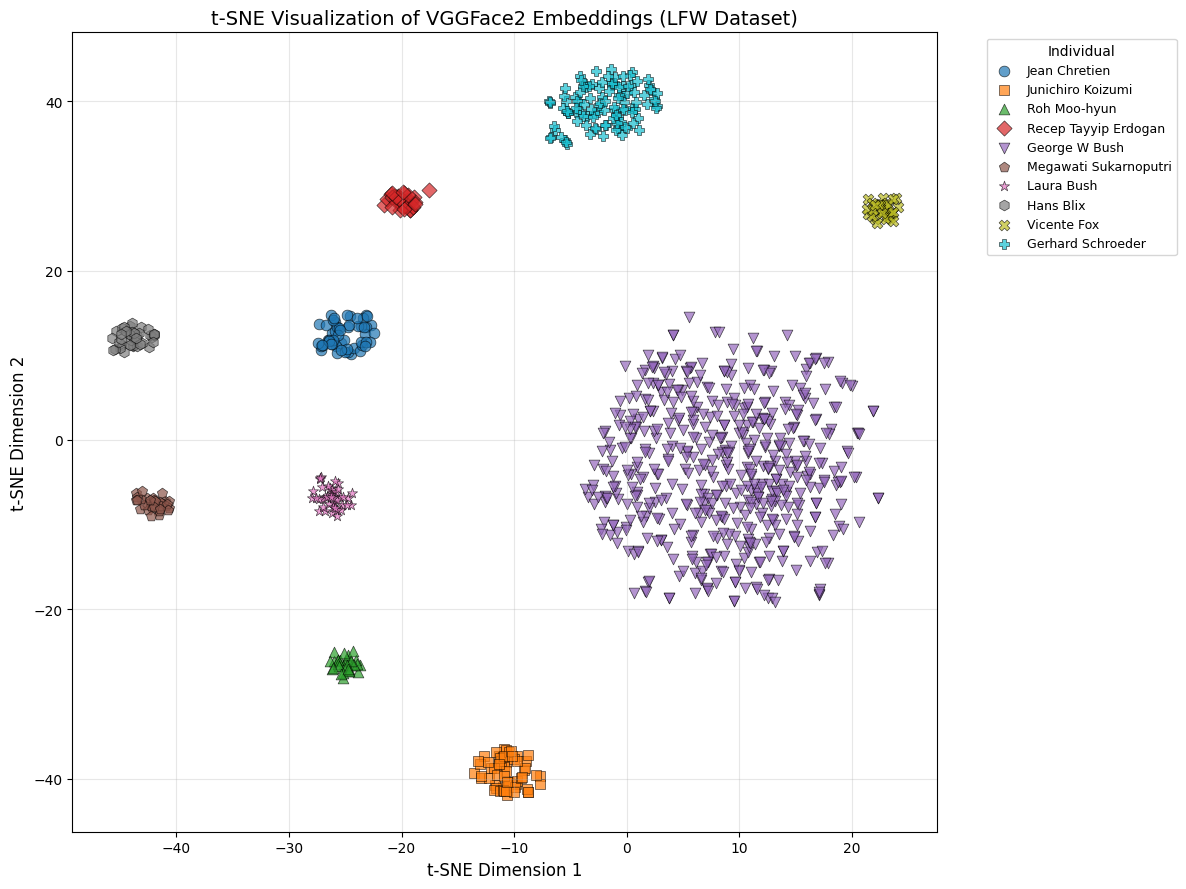


Visualization complete.
Total faces plotted: 959
Individuals shown: 10


In [11]:
# LFW dataset
# generate t-SNE scatter plot
plt.figure(figsize=(12, 9))
colors = plt.cm.tab10(np.linspace(0, 1, num_people))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', 'P']

for i in range(num_people):
    mask = valid_labels == i
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        marker=markers[i % len(markers)],
        label=selected_names[i],
        alpha=0.7,
        edgecolors='black',
        linewidths=0.5,
        s=60
    )

plt.title('t-SNE Visualization of VGGFace2 Embeddings (LFW Dataset)', fontsize=14)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(
    title='Individual',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=9
)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nVisualization complete.")
print(f"Total faces plotted: {len(embeddings_2d)}")
print(f"Individuals shown: {num_people}")